In [5]:
import pandas as pd

In [6]:
import pickle

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [8]:
import mlflow

mlflow.set_tracking_uri('sqlite:////home/ubuntu/Mlops-course/03-experiment-tracking/mlflow.db')
mlflow.set_experiment('nyc_taxi_experiment')


<Experiment: artifact_location='/home/ubuntu/Mlops-course/02-ml-model/mlruns/1', creation_time=1783744047989, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783744047989, lifecycle_stage='active', name='nyc_taxi_experiment', tags={}, trace_location=None, workspace='default'>

In [9]:
df = pd.read_parquet("../data/green_tripdata_2021-01.parquet")

df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [10]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
Y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_train)

mean_squared_error(Y_train, y_pred)

96.80198150112638

/tmp/ipykernel_48375/3025887165.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label = 'prediction')
/tmp/ipykernel_48375/3025887165.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y_train, label = 'actual')


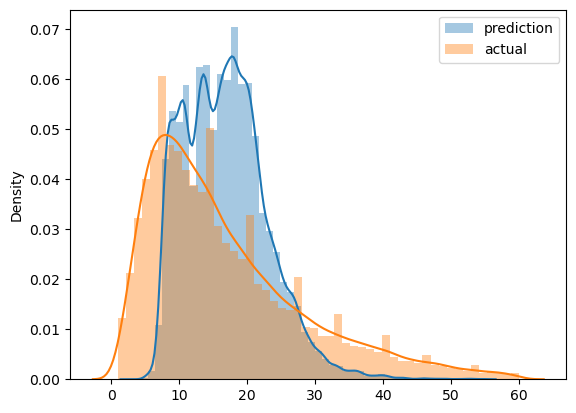

In [11]:
sns.distplot(y_pred, label = 'prediction')
sns.distplot(Y_train, label = 'actual')

plt.legend()

In [12]:
def read_dataframe(fileName): #"./notebook/data/green_tripdata_2021-01.parquet"
    df = pd.read_parquet(fileName)

    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    
    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )
    
    df = df[(df.duration >= 1) & (df.duration <= 60)]
    
    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

In [13]:
df_train = read_dataframe("../data/green_tripdata_2021-01.parquet")
df_val =read_dataframe("../data/green_tripdata_2021-02.parquet")

In [14]:
len(df_train), len(df_val)

(73908, 61921)

In [15]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [16]:
categorical = ['PU_DO'] # 'PULocationID', 'DOLocationID'
numerical = ['trip_distance']
dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)



In [17]:
target = 'duration'
Y_train = df_train[target].values
y_val = df_val[target].values

In [18]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

60.197661613134706

In [19]:
with open('../models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [20]:
with mlflow.start_run():
    
    mlflow.set_tag("developer", "Alfredo")

    mlflow.log_param('train-data-path','../data/green_tripdata_2021-01.parquet')
    mlflow.log_param('valid-data-path','../data/green_tripdata_2021-02.parquet')

    alpha = 0.01    
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, Y_train)

    y_pred = lr.predict(X_val)
    rmse = mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

In [21]:
import xgboost as xgb

In [22]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [23]:
train = xgb.DMatrix(X_train, label=Y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [ ]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/home/ubuntu/anaconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [22:15:02] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:7.01449                           
[1]	validation-rmse:6.71988                           
[2]	validation-rmse:6.69382                           
[3]	validation-rmse:6.68409                           
[4]	validation-rmse:6.67993                           
[5]	validation-rmse:6.67639                           
[6]	validation-rmse:6.66899                           
[7]	validation-rmse:6.66406                           
[8]	validation-rmse:6.66075                           
[9]	validation-rmse:6.65695                           
[10]	validation-rmse:6.64985                          
[11]	validation-rmse:6.64710                          
[12]	validation-rmse:6.64592                          
[13]	validation-rmse:6.64180                          
[14]	validation-rmse:6.63985                          
[15]	validation-rmse:6.64433                          
[16]	validation-rmse:6.63768                          
[17]	validation-rmse:6.63708                          
[18]	valid